# Analyze global fit results

In [1]:
import numpy as np
import sys
import os
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 600


sys.path.append(os.path.abspath("/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/"))

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport fit_utils
%aimport fit_utils.utils
%aimport fit_utils.pullplots
%aimport fit_utils.parser

import fit_utils.utils as utils
import fit_utils.pullplots as pullplots
import fit_utils.parser as parser

In [2]:
model = "Z2SSM"
working_dir = "."

all_scenarios = [
    # f"{model}_FCCee240"
    f"{model}_FCCee240_FCCee365"
    # f"{model}_FCCee240_FCCee365_HLLHClambda"
]

specs = [
    # "fits_long",
    # "fits_full",
    # "fits_realistic_HL_LHC_WFR_kala2_input_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_no_C_HG_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_no_HLLHC_Higgs_small_priors_long",
    "fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_realistic_HL_LHC_long",
    # "fits_realistic_HL_LHC_all_EW_mods_long",
    # "fits_realistic_HL_LHC_no_1L_BSM_sqrt_s_long",
    # "fits_realistic_HL_LHC_no_1L_BSM_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_sqrt_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_small_priors_long",
    "fits_realistic_HL_LHC_smeft_formula_all_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_no_C_HG_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_external_leg_small_priors_long",
    # "fits_realistic_HL_LHC_small_priors_long",
    # "fits_realistic_HL_LHC_no_quad_long",
    # "fits_realistic_HL_LHC_noLoopH3d6Quad_long",
    # "fits_realistic_HL_LHC_noLoopH3d6Quad_no_quad_long",
    # "fits_realistic_HL_LHC_LoopHd6noWFR_no_quad_long",
    # "fits_realistic_HL_LHC_LoopHd6noWFR_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
]

spec_labels_dict = {
    "fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long" : "Original",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long" : "Using HEPfit C1 values",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long" : "Using HEPfit C1 values \n(including decay rates)",
    "fits_realistic_HL_LHC_smeft_formula_all_small_priors_long" : "Using HEPfit formulas",
}
spec_labels = list(spec_labels_dict.values())

model_specs = {
    # f"{model}_FCCee240" : specs
    f"{model}_FCCee240_FCCee365" : specs,
    # f"{model}_FCCee240_FCCee365_HLLHClambda" : specs,
}
scenario_titles_dict = {
    # f"{model}_FCCee240" : rf"FCC-ee$_{{240}}$",
    f"{model}_FCCee240_FCCee365" : rf"FCC-ee$_{{240}}$ + FCC-ee$_{{365}}$",
    # f"{model}_FCCee240_FCCee365_HLLHClambda" : rf"FCC-ee$_{{240}}$ + FCC-ee$_{{365}}$ + $\kappa_{{\lambda}}$ at HL-LHC",
}
scenario_titles = list(scenario_titles_dict.values())

model_specs_labels = {
    # f"{model}_FCCee240" : specs
    f"{model}_FCCee240_FCCee365" : spec_labels,
    # f"{model}_FCCee240_FCCee365_HLLHClambda" : specs,
}


results_dirs = specs
# results_dirs = [ model_specs["IDM_FCCee240_FCCee365"] for spec in specs ]
# results_dir = "comparison_NPs_scaled"
results_dir_compare = "comparison_original_HEPfitC1_C1decayrates_SMEFTformula"

# num_BPs = 8
# BPs = [f"BP_{i}" for i in range(num_BPs)]
BPs = []

# num_BPOs = 2
# BPOs = [f"BPO_{i}" for i in range(num_BPOs)]
BPOs = []

# num_BPBs = 17
# BPBs = [f"BPO_{i}" for i in range(num_BPBs)]
BPBs = []

# num_BPBnews = 14
# BPBnews = [f"BPBnew_{i}" for i in range(num_BPBnews)]
BPBnews = ["BPBnew_0", "BPBnew_1", "BPBnew_2", "BPBnew_4", ]
# BPBnews = []

BPs = BPs + BPOs + BPBs + BPBnews

BP_names = [f"BP {i}" for i in range(len(BPs))]

BP_lambdas_all = [
    1.0643594459030925, # BPB_0
    2.068362744578383,  # BPB_1
    3.41660475844658,   # BPB_2
    0.9197317035823376, # BPB_3
    4.996504503173265,  # BPB_4
    2.723103795696014,  # BPB_5
    6.114019817191308,  # BPB_6
    4.878015572616551,  # BPB_7
    7.24831645311373,   # BPB_8
    7.005268951781772,  # BPB_9
    8.535635929341407,  # BPB_10
    8.84021000223677,   # BPB_11
    9.584476423981522,  # BPB_12
    10.34814810189343,  # BPB_13
]

BP_lambdas_0124 = [
    1.0643594459030925, # BPB_0
    2.068362744578383,  # BPB_1
    3.41660475844658,   # BPB_2
    4.996504503173265,  # BPB_4
]

plot_titles = { 
    scenario : { 
        # spec : f"{scenario_titles_dict[scenario]} scenario \n{spec_labels_dict[spec]}" 
        spec : f"{spec_labels_dict[spec]}" 
        for spec in model_specs[scenario] 
    } 
    for scenario in all_scenarios
}

## Copy kappa_lambda distributions to the `comparison_plots` directory

In [3]:
utils.group_plots(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
)

Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/deltalHHH_HLLHC_mod_BPBnew_0_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/deltalHHH_HLLHC_mod_BPBnew_1_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/deltalHHH_HLLHC_mod_BPBnew_2_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/deltalHHH_HLLHC_mod_BPBnew_4_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long/deltalHHH_HLLHC_mod_BPBnew_0_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_p

## Print $\kappa_\lambda$ results to a text file
For each model specification and collider scenario

In [4]:
utils.print_klam_results(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
)


Reading klam fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_smeft_formula_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee24

## Compare $\kappa_\lambda$ results between benchmark points
For each model specification and collider scenario


Reading klam fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_smeft_formula_all_small_priors_long/Observables/Statistics.txt


Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_smeft_formula_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_re

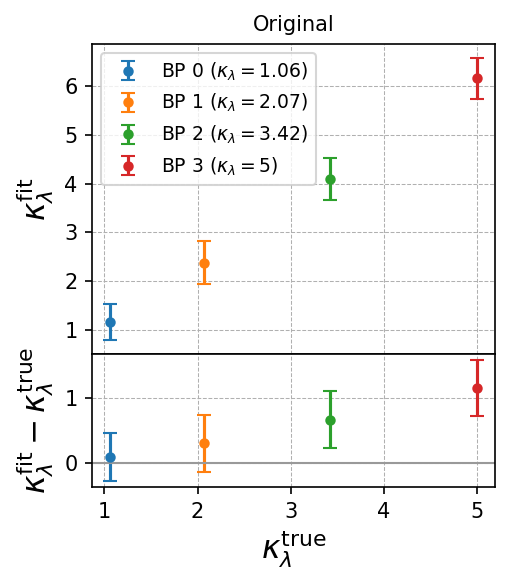

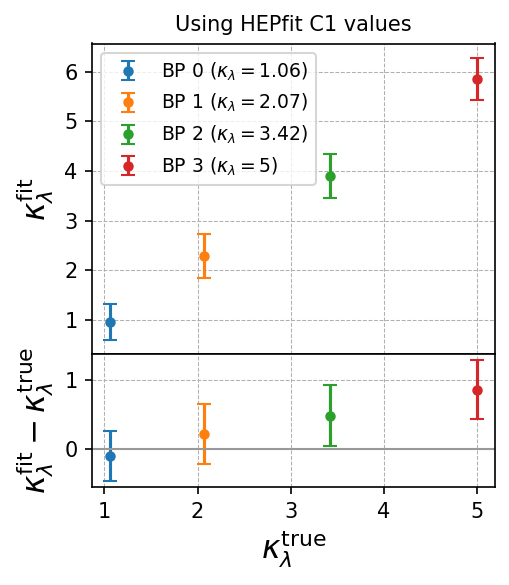

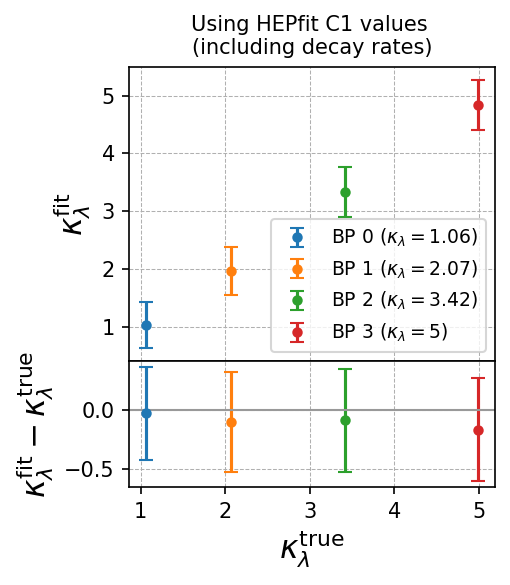

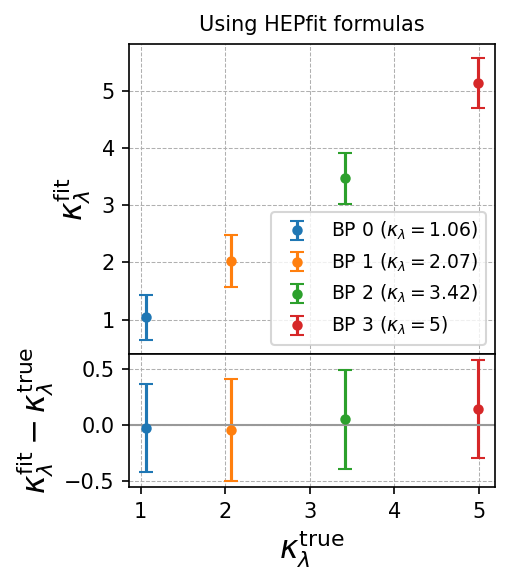

In [5]:
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red",]

utils.generate_klam_comparison_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=None,
    plot_titles=plot_titles,
    colors=colors,
    show_plots=True,
)

## Compare the posterior $\kappa_\lambda$ distribution between different model specifications

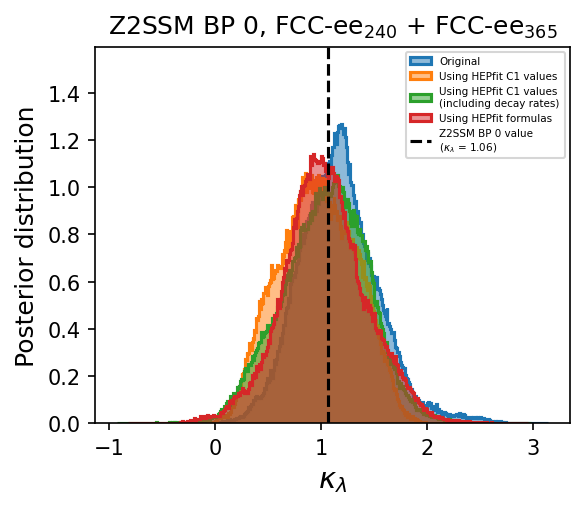

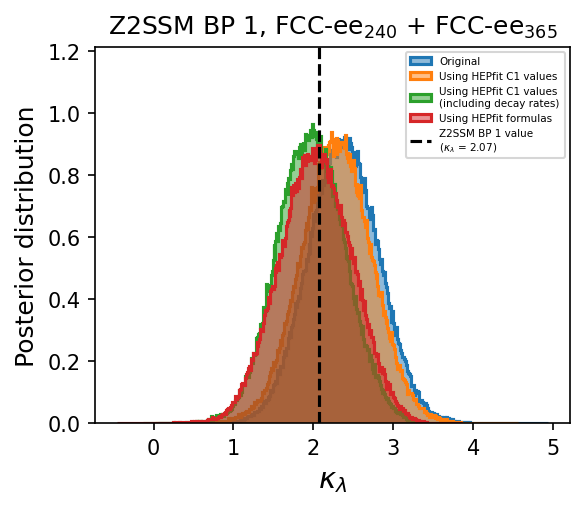

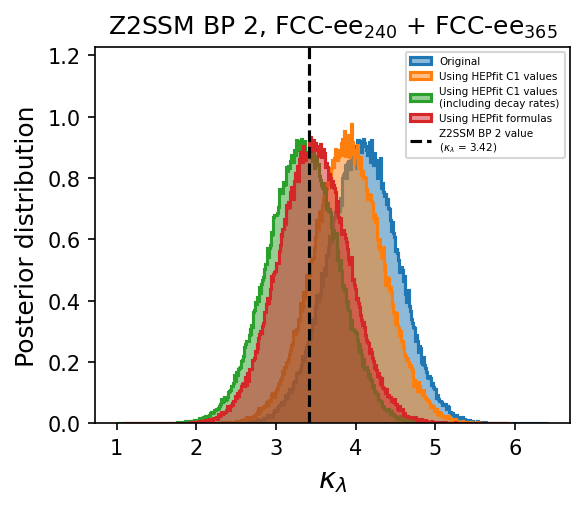

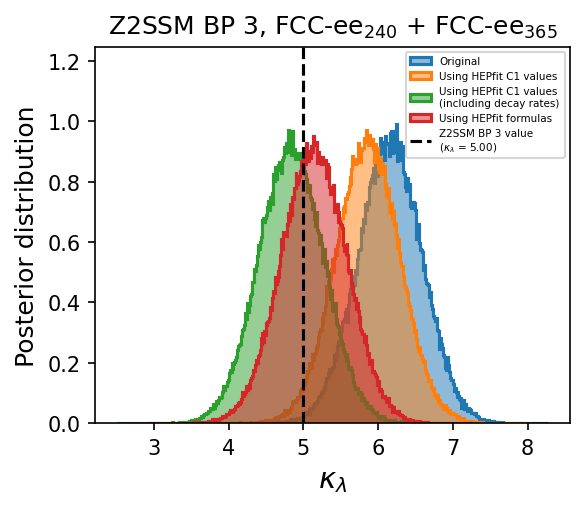

In [6]:
# colors = ["tab:red", "tab:blue"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red",]

utils.compare_BP_results_uproot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    spec_labels=spec_labels,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    scenario_titles=None,
    plot_titles=None,
    colors=colors,
    show_plots=True,
    legend_fontsize=5.,
)

## Generate summary $\LaTeX$ table for $\kappa_\lambda$ results

In [8]:
utils.generate_klam_latex_table(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    spec_labels=spec_labels,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
)


Reading klam fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_smeft_formula_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee24

## Generate pull plots for parameters


Finding configuration files for the observables

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long
Full fit flag: WFR_kala2_input_all_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long
Full fit flag: use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Full fit flag: use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_smeft_

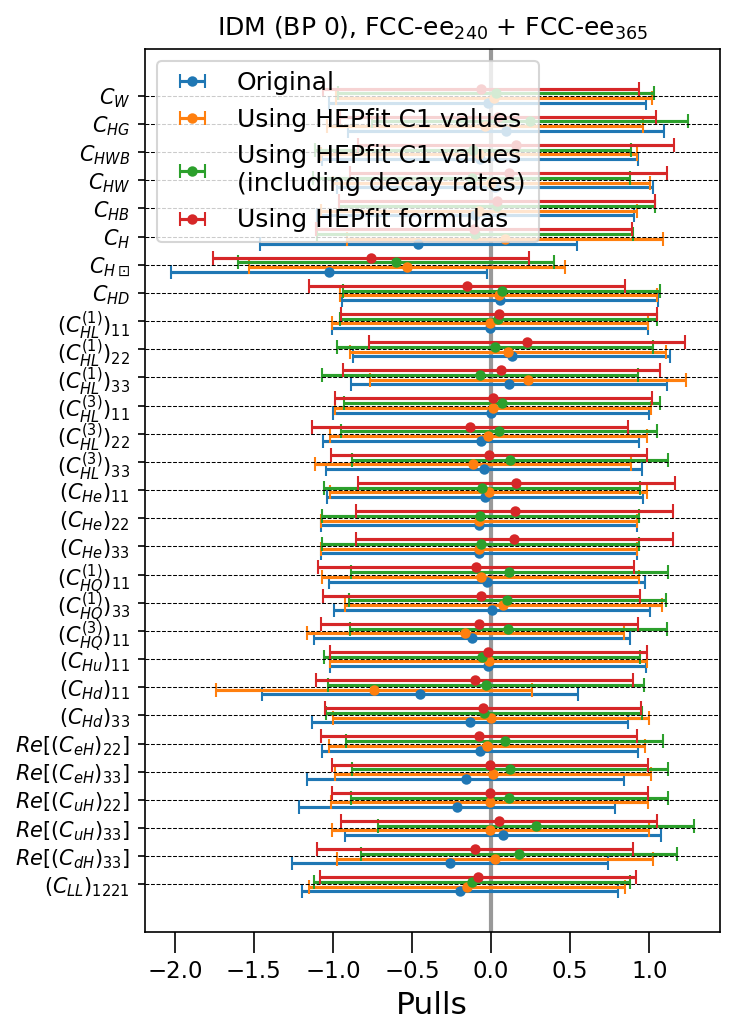

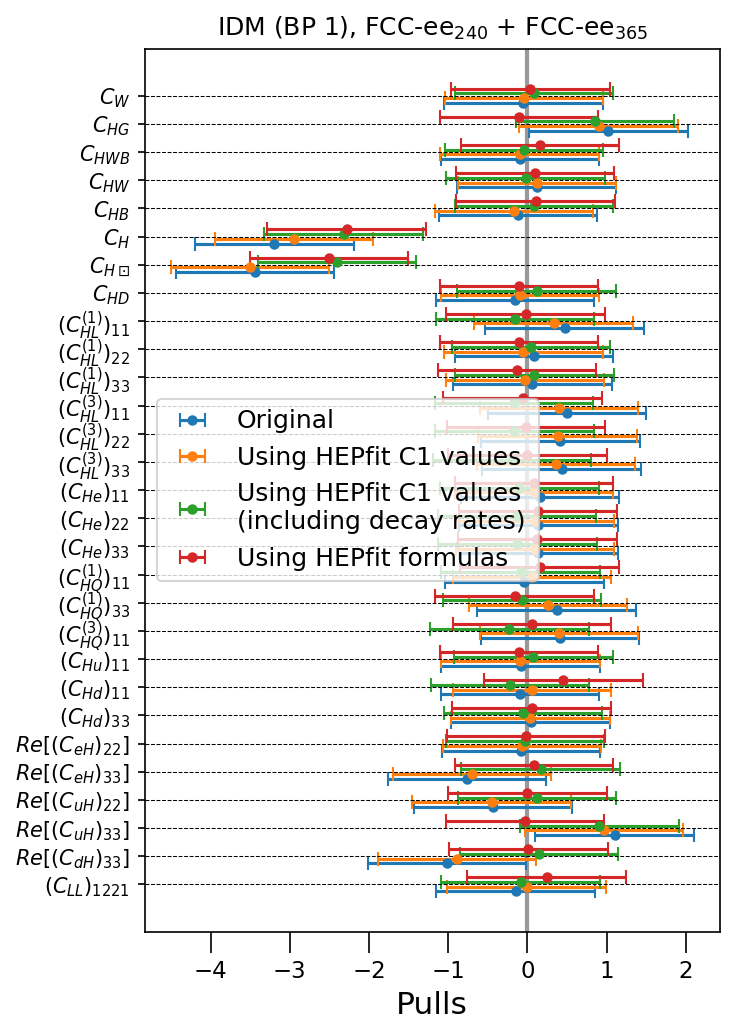

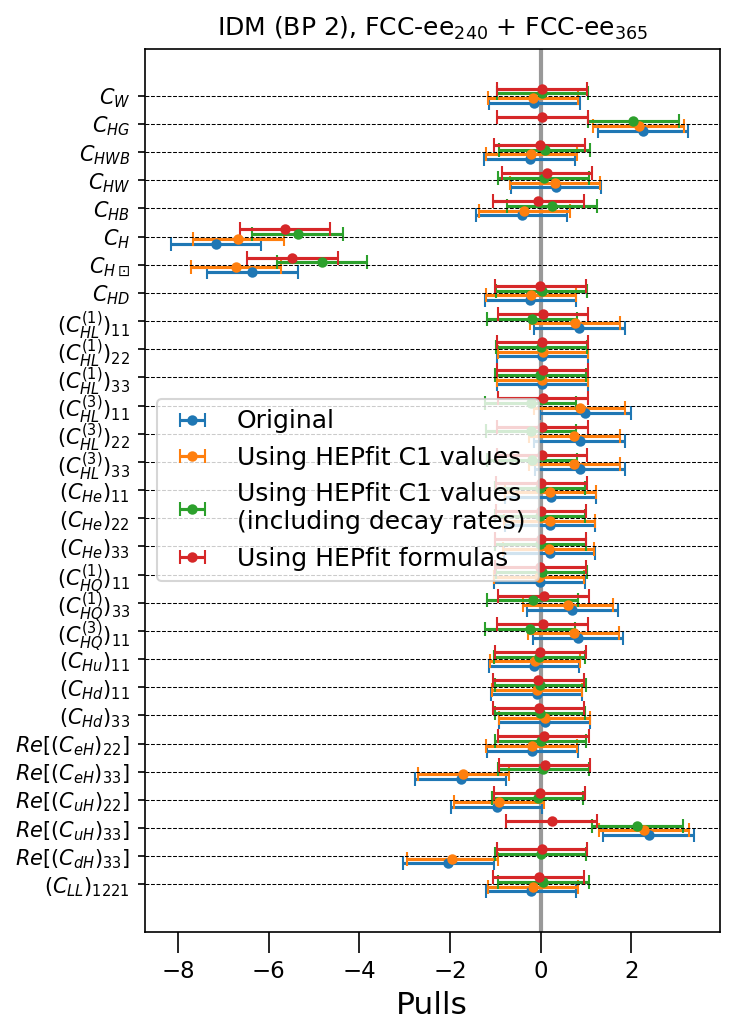

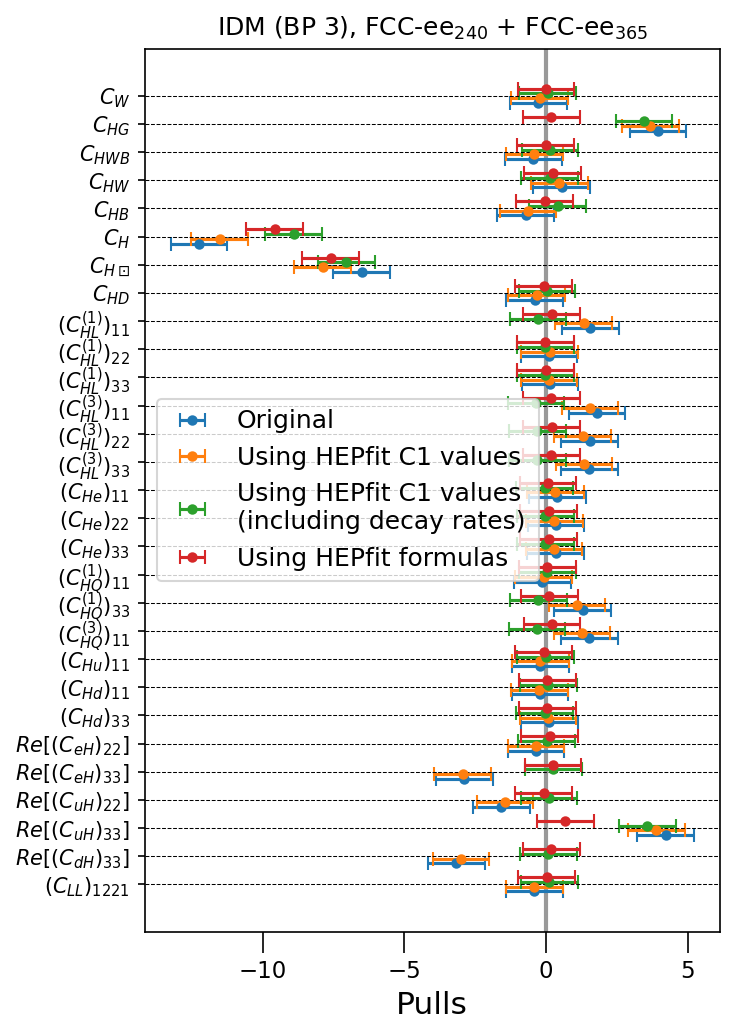

In [9]:
pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 7),
)

## Generate pull plots for observables


Finding configuration files for the observables

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long
Full fit flag: WFR_kala2_input_all_small_priors_long
Files considered:
- ObservablesEW.conf
- ObservablesEW_Current_SM_noLFU.conf
- ObservablesEW_FCCee_Zpole_SM_kappa_scaled.conf
- ObservablesEW_FCCee_WW_SM_kappa_scaled.conf
- ObservablesEW_HLLHC_kappa_scaled.conf
- ObservablesHiggs_WFR_kala2_input_all.conf
- ObservablesHiggs_FCCee_240_SM_kappa_scaled_WFR_kala2_input_all.conf
- ObservablesHiggs_HLLHC_SM_kappa_scaled_WFR_kala2_input_all.conf
- ObservablesVV.conf
- aTGC_observables_Current.conf
- aTGC_observables_HLLHC_Full.conf
- ObservablesVV_OO_FCCee_161.conf
- ObservablesVV_OO_FCCee_240.conf
- EffVHcouplings_QFU12.conf
- HiggsEW_Par_Corr.conf
- ObservablesHiggs_FCCee_365_kappa_scaled_WFR_kala2_input_all.conf
- ObservablesVV_OO_FCCee_365.conf

Setting configuration files for scenario: Z2SSM_FCCee240_

/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][model_spec][:,1] / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][

137
[  0  50 100 137]


/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][model_spec][:,1] / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][

137
[  0  50 100 137]


/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][model_spec][:,1] / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][

137
[  0  50 100 137]


/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][model_spec][:,1] / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][

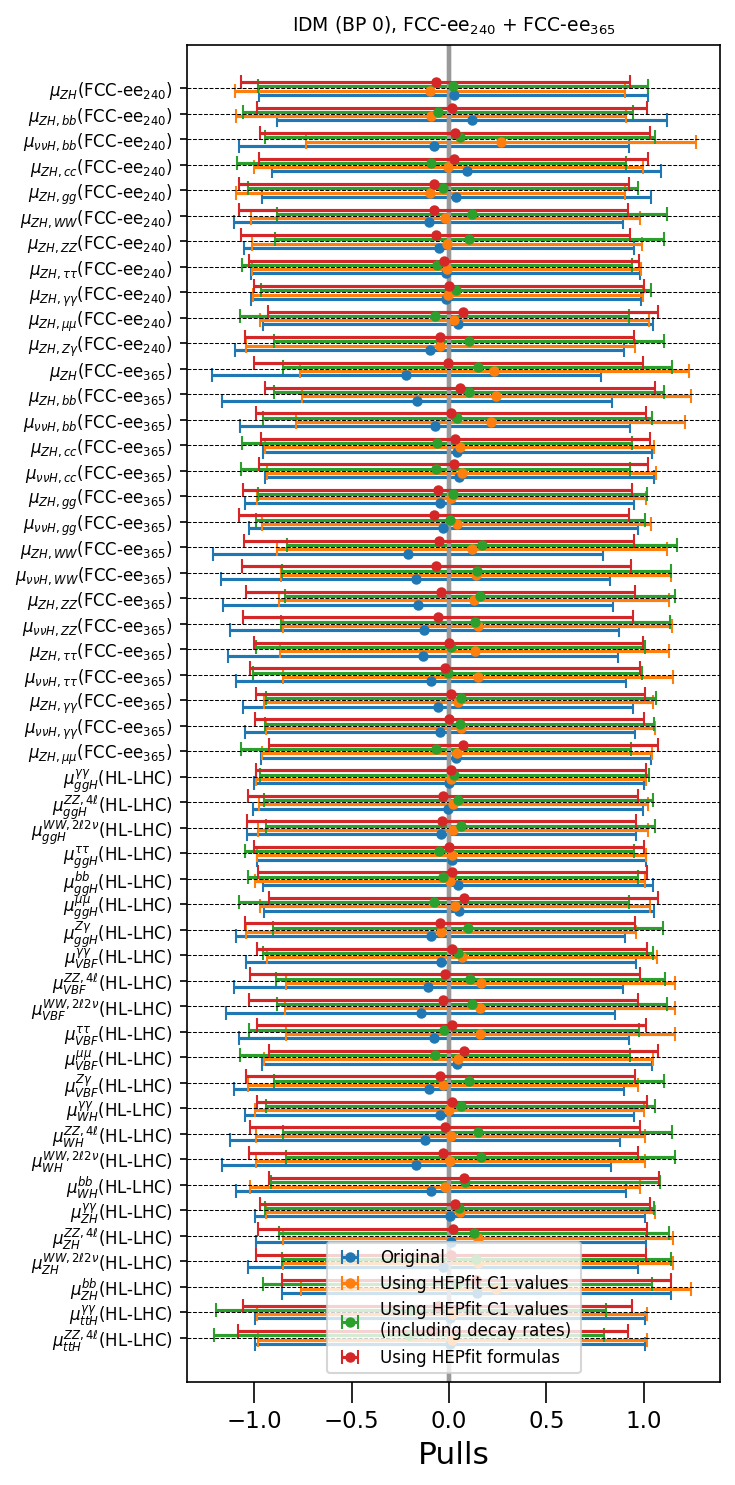

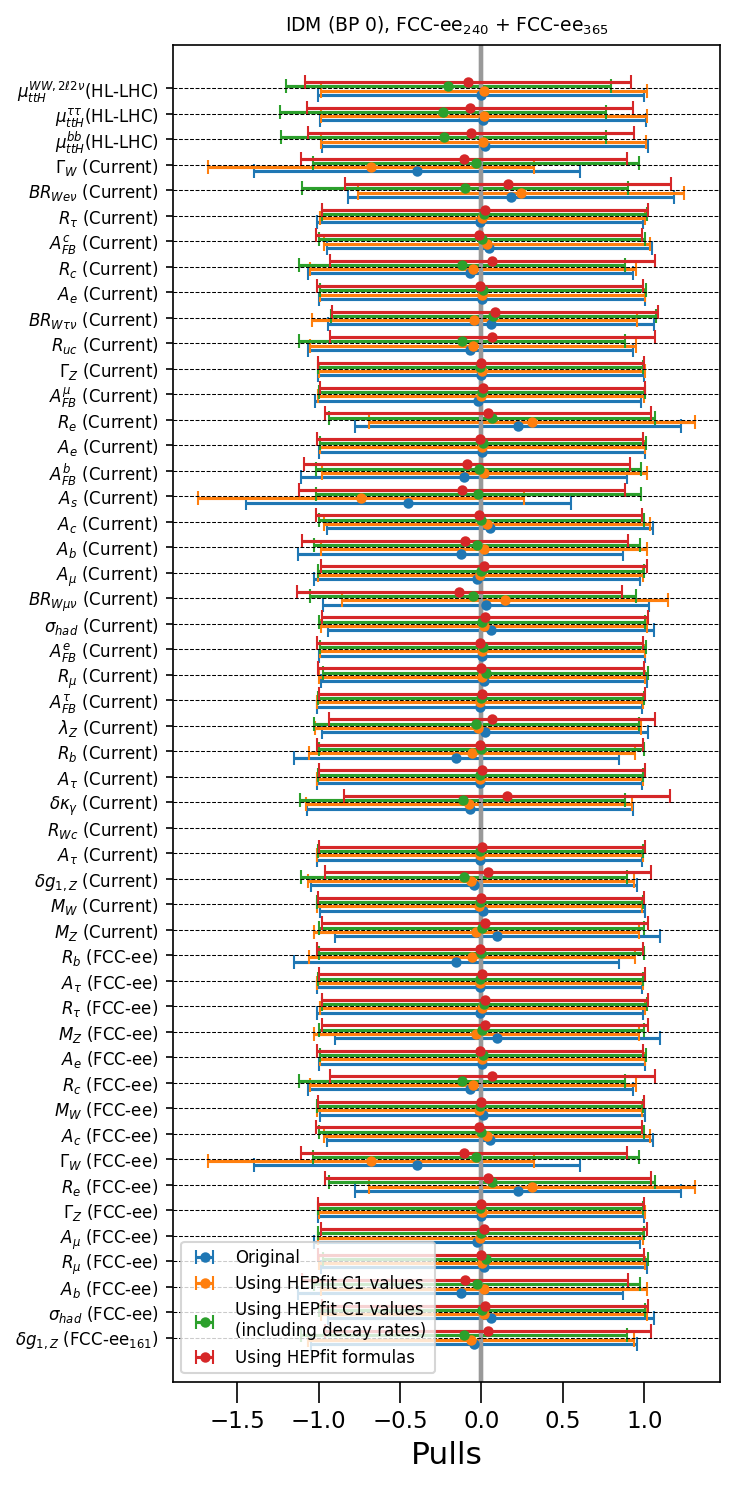

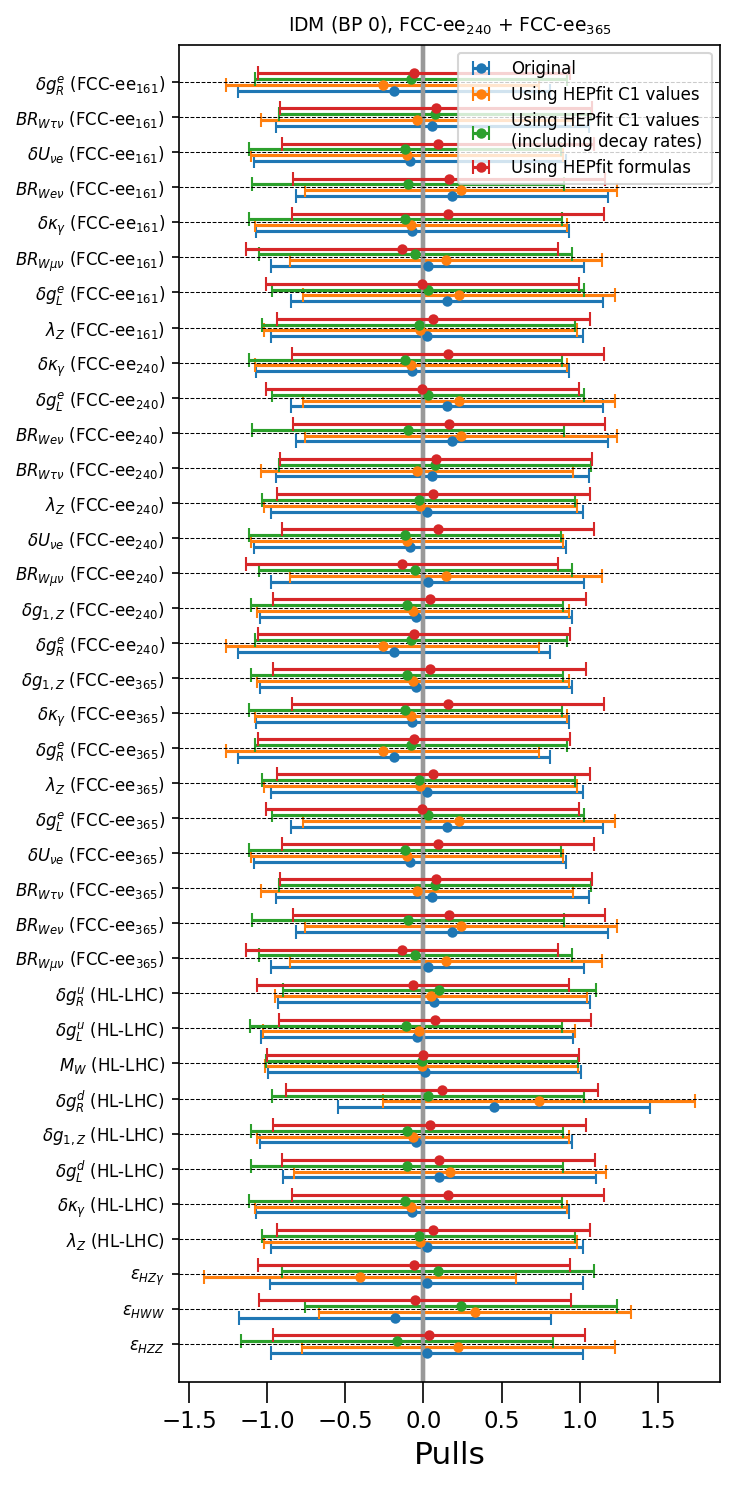

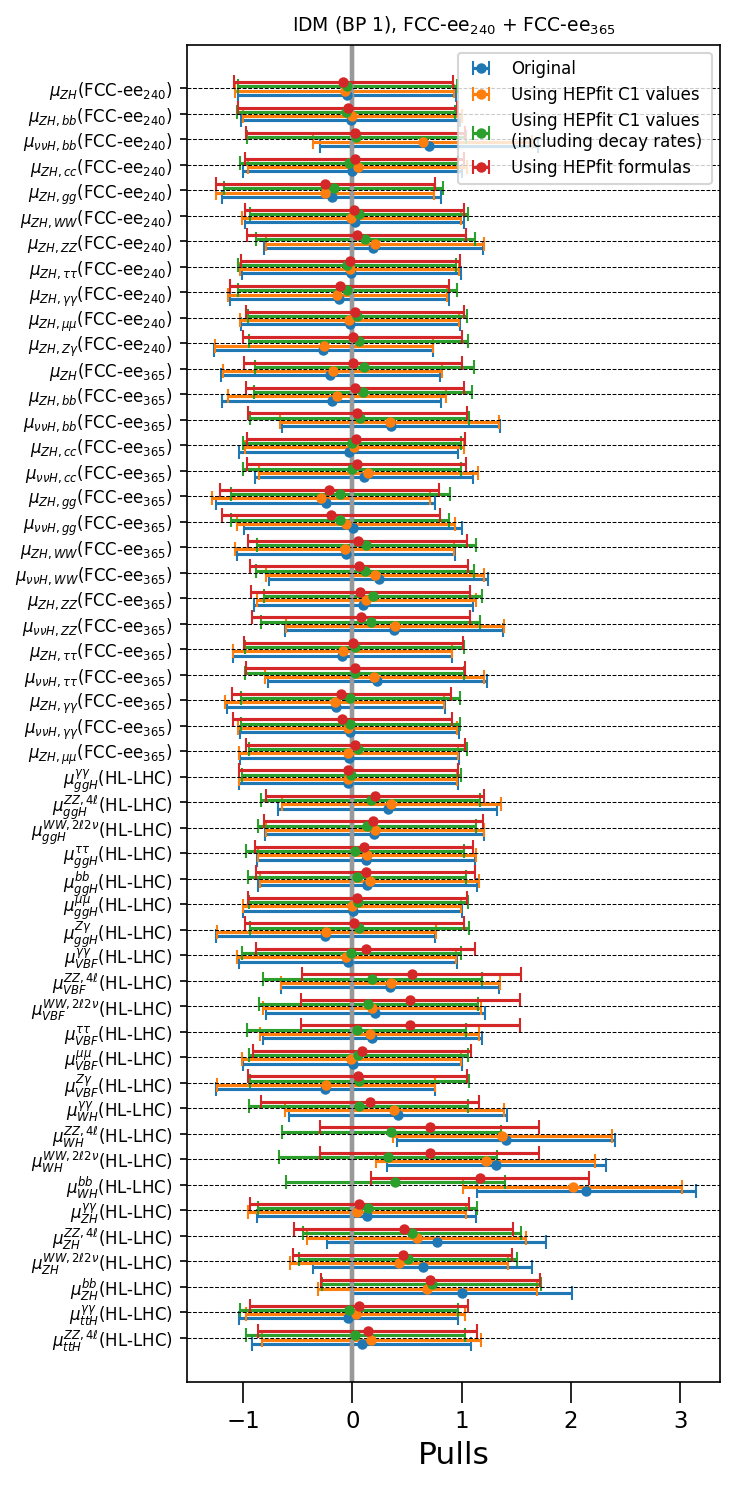

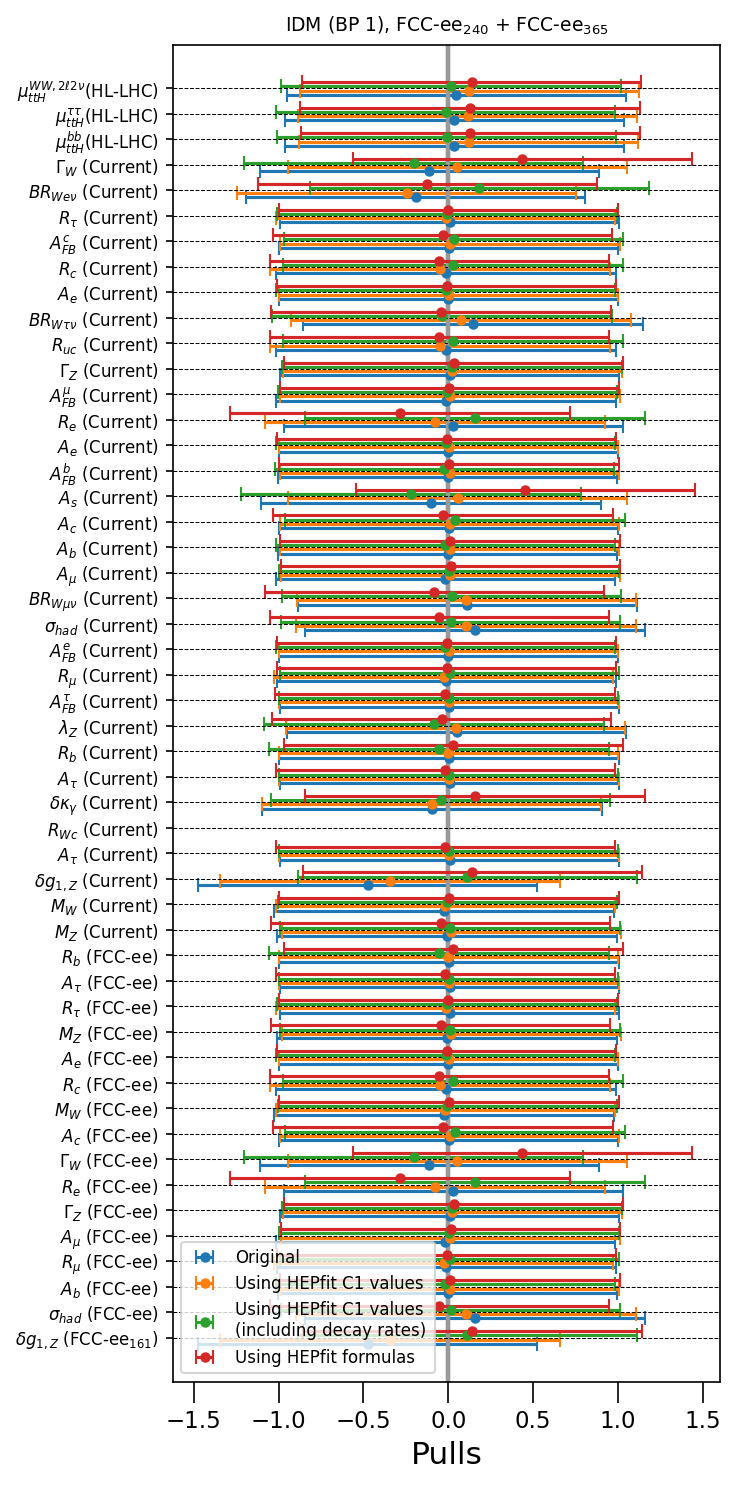

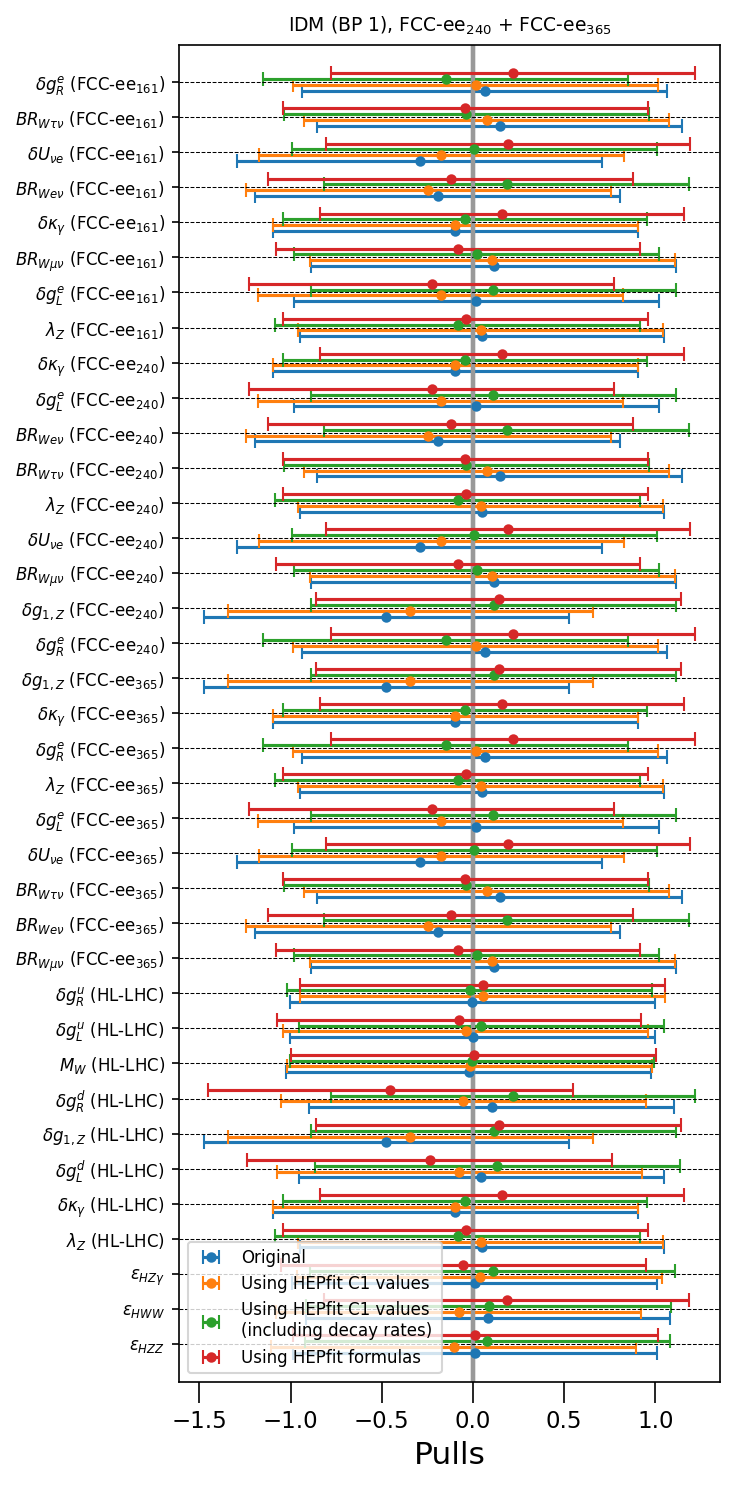

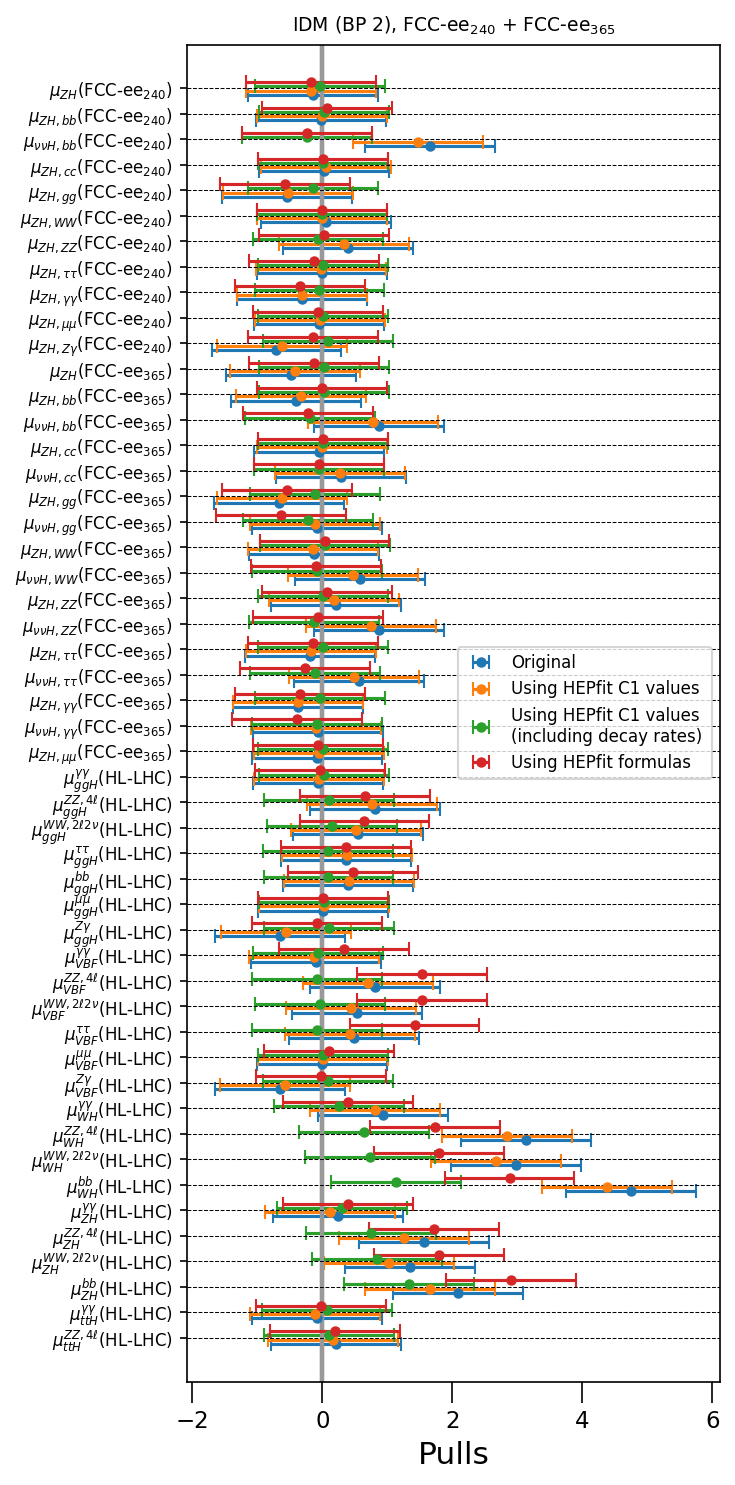

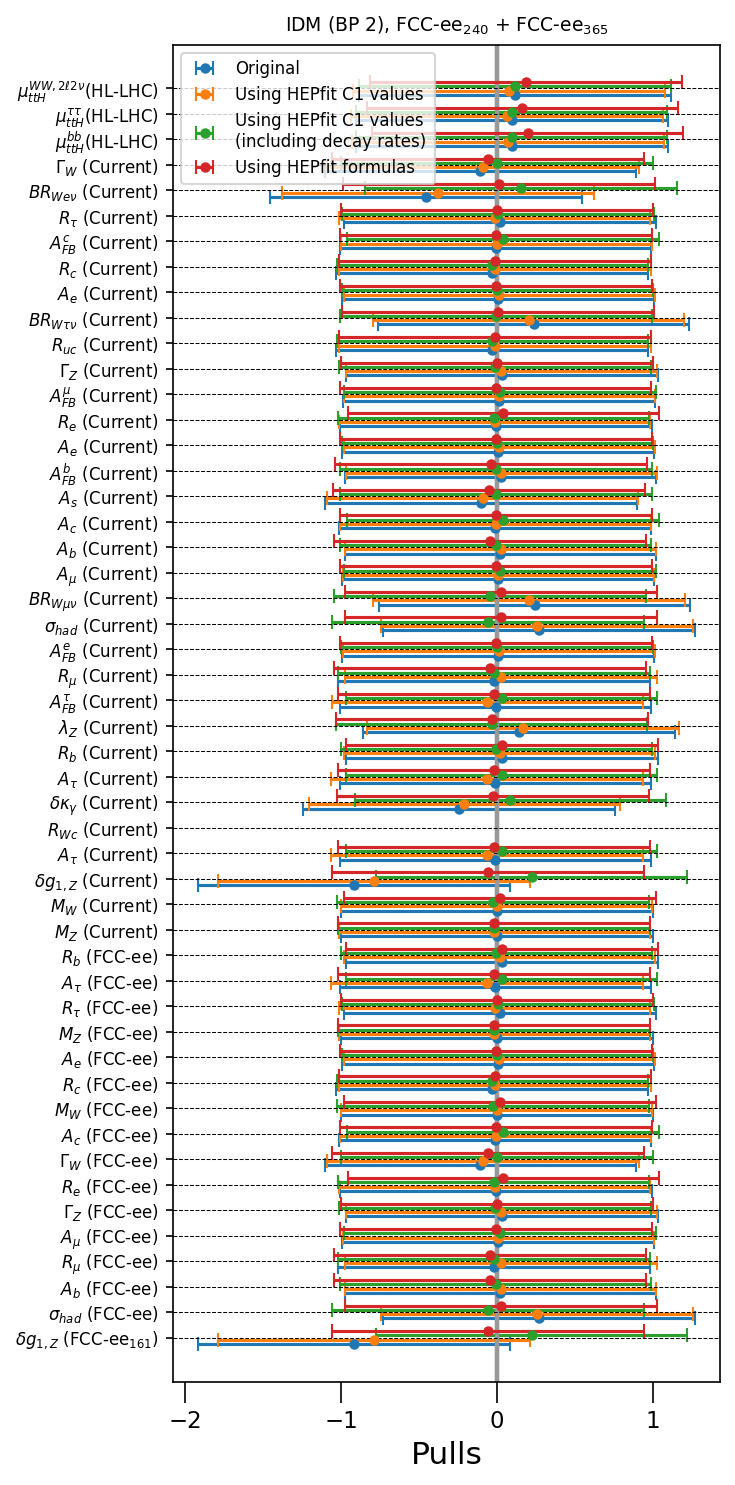

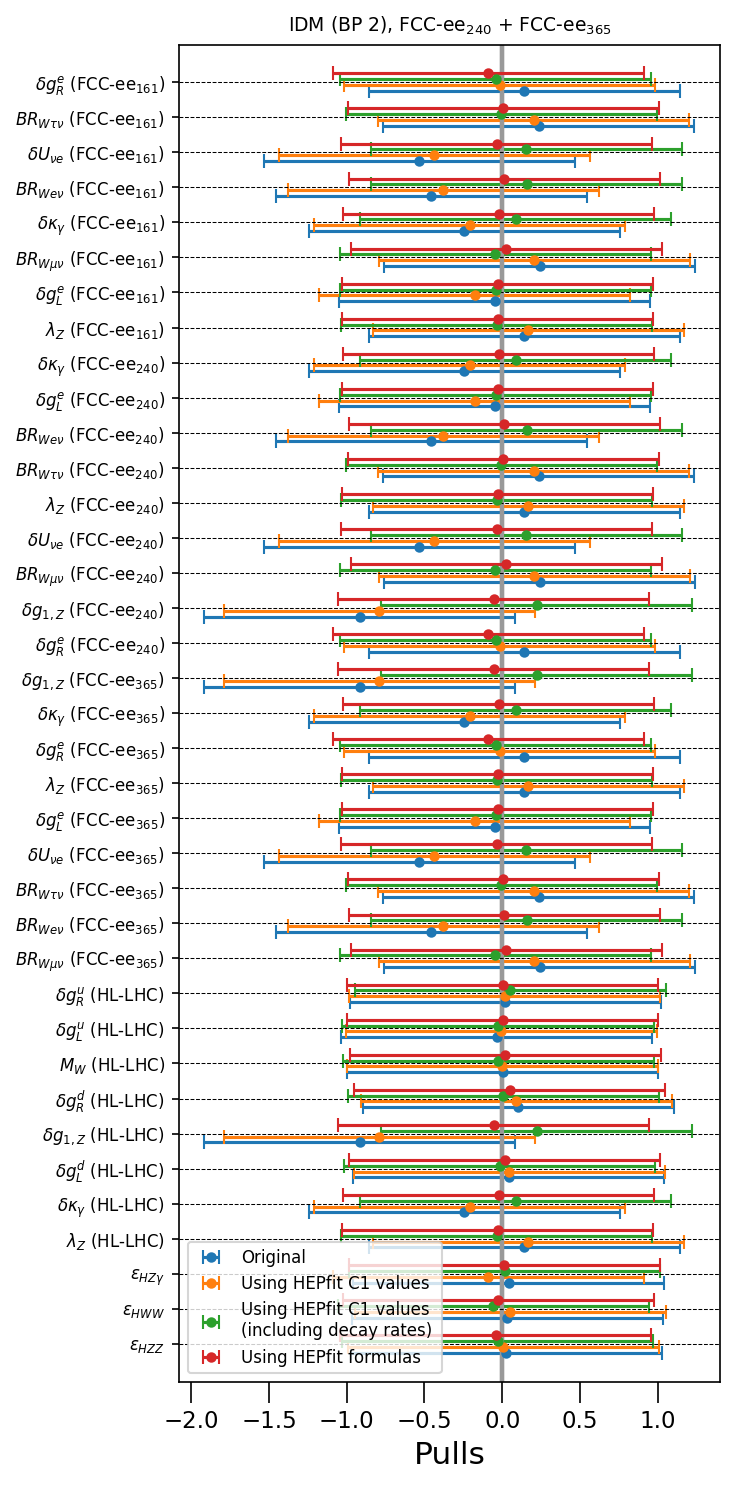

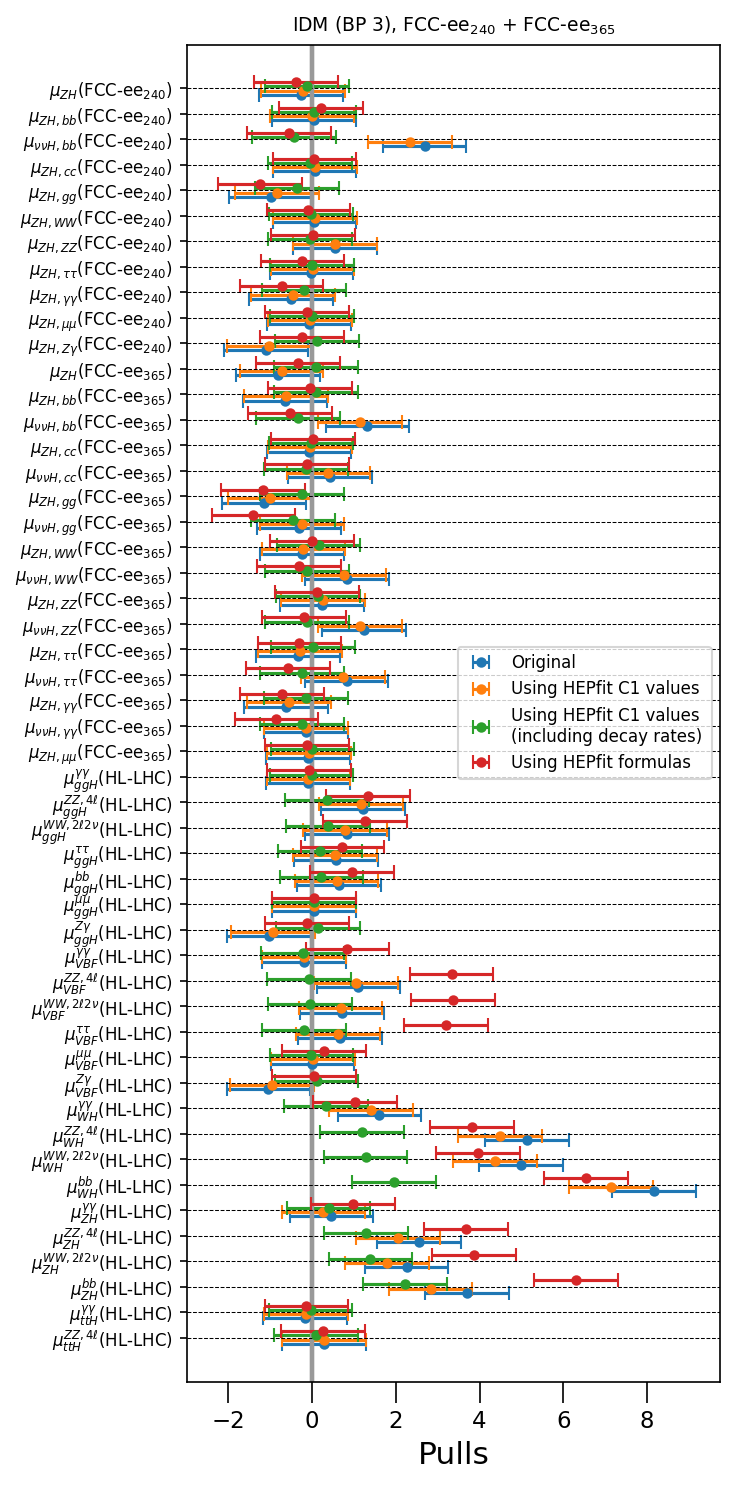

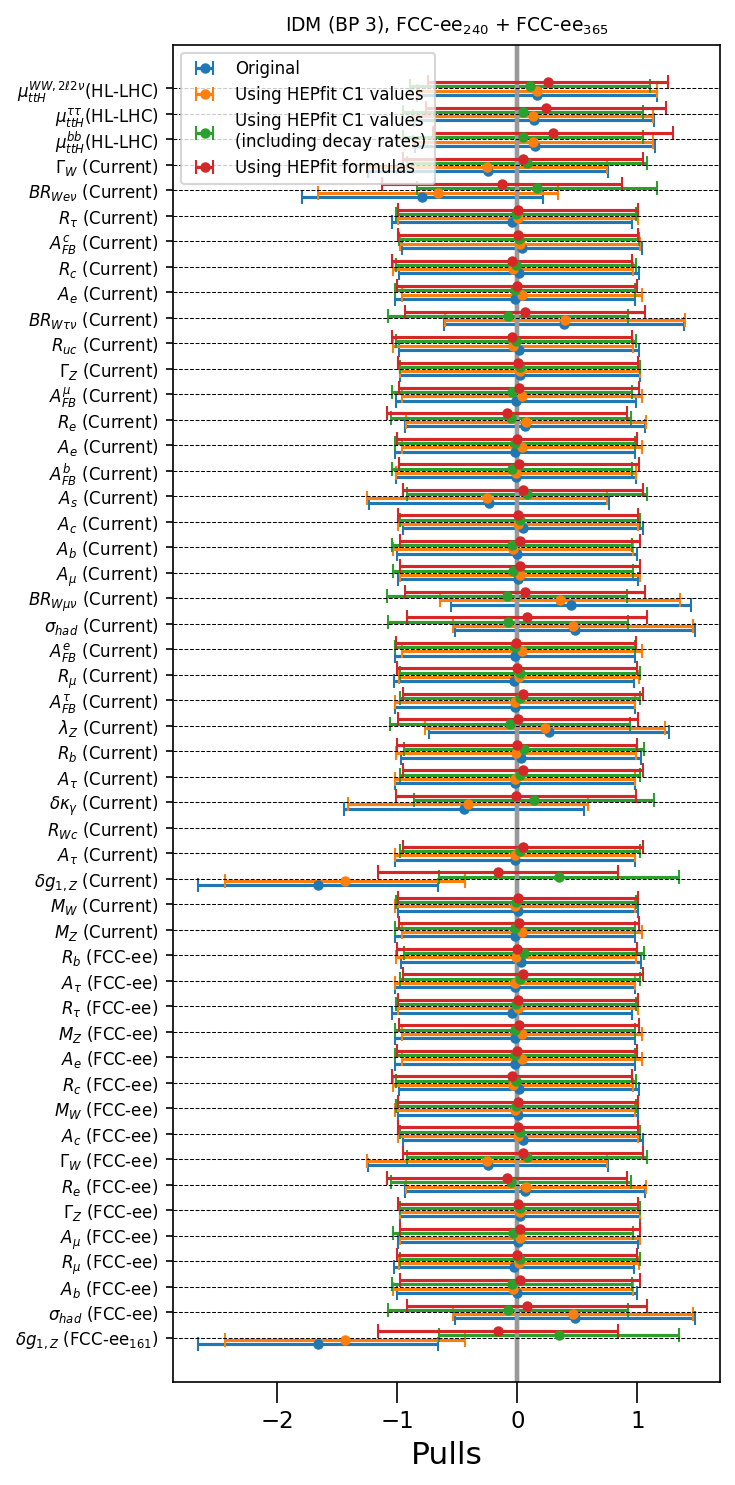

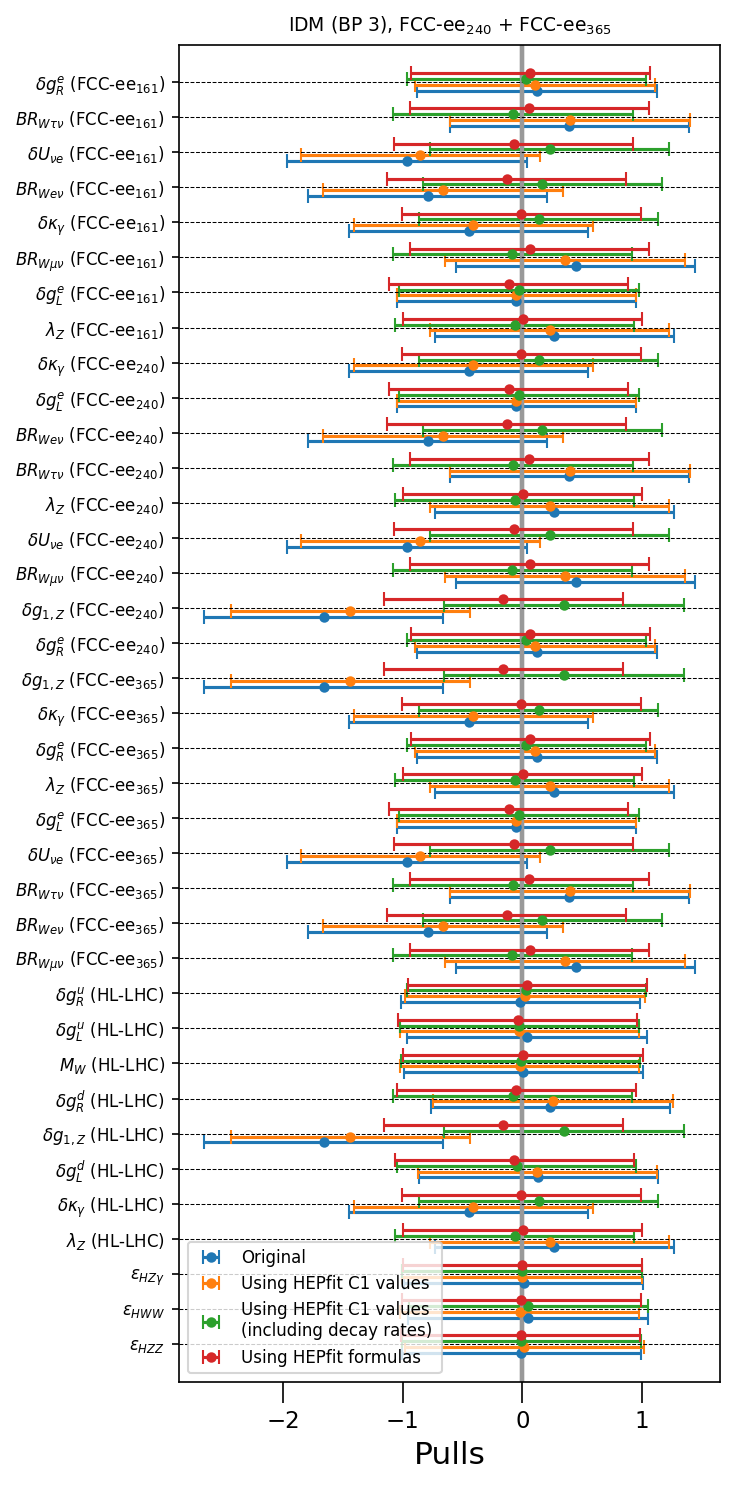

In [10]:
plot_titles = { 
    BP : {
        scenario : rf"IDM ({BP_name}), {scenario_title}"
        for scenario, scenario_title in zip(all_scenarios, scenario_titles)
    } 
    for BP, BP_name in zip(BPs, BP_names)
}

pullplots.generate_pull_plots_obs(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 10),
)